In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.datasets import make_classification
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [3]:
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


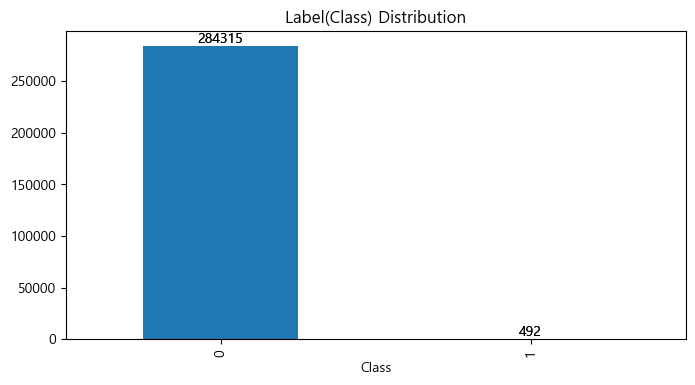

In [5]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=True)

In [6]:
# 1-2. get_outlier로 이상치 요약 (행 drop X, EDA용)
#     -> describe() 결과를 넣는 게 이 구현과 잘 맞음
outlier_info = uu.get_outlier(df.describe())
print(outlier_info.head())

⚠️ 경고: describe() 결과로는 이상치 개수를 계산할 수 없습니다.
   원본 데이터를 입력하면 정확한 개수를 계산할 수 있습니다.

이상치 탐지 결과 (IQR weight: 1.5)

            min    LowerBound            Q1             Q3           IQR  \
Time   0.000000 -73477.000000  54201.500000  139320.500000  85119.000000   
V1   -56.407510     -4.274396     -0.920373       1.315642      2.236015   
V2   -72.715728     -2.701961     -0.598550       0.803724      1.402274   
V3   -48.325589     -3.766705     -0.890365       1.027196      1.917560   
V4    -5.683171     -3.236612     -0.848640       0.743341      1.591981   

                max     UpperBound  OutlierCount  
Time  172792.000000  266999.000000           NaN  
V1         2.454930       4.669664           NaN  
V2        22.057729       2.907135           NaN  
V3         9.382558       3.903536           NaN  
V4        16.875344       3.131313           NaN  


In [7]:
# 1-3. 모델링용 컬럼 선택
#   - Time 제거
#   - Class는 target으로 분리할 거라 유지
df_model = df.drop(columns=["Time"])

In [8]:
# 1-4. X, y 분리 (Class를 타겟으로 사용)
X_all, y_all = pp.split_features_target(df_model, target_col="Class")

# 1-5. train / test 분리 (stratify 필수)
X_train, X_test, y_train, y_test = pp.data_split(X_all, y_all)

In [9]:
# =========================
# 2) HyperOpt용 train/val 분리 + 스케일링
# =========================

# 2-1. HyperOpt를 위한 inner train / val 분리
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=23,
    stratify=y_train
)

In [10]:
# 2-2. StandardScaler로 전체 피처 스케일링
feature_cols = X_train.columns.tolist()

X_tr_scaled, X_val_scaled, scaler_inner = pp.scale_selected_columns(
    X_tr_raw,
    X_val_raw,
    columns=feature_cols
)

In [11]:
# =========================
# 3) HyperOptTuner 설정
# =========================

# metric은 사기 탐지 특성상 recall이나 f1 중 하나 택 1
tuner = uu.HyperOptTuner(
    max_evals=50,
    metric="recall",   # 필요하면 "f1"로 변경 가능
    random_state=23
)

In [12]:
# =========================
# 4) LogisticRegression HyperOpt
# =========================

log_model = LogisticRegression()

log_search_space = {
    # 정규화 강도 (작을수록 규제가 강함)
    "C": hp.loguniform("C", np.log(1e-3), np.log(10.0)),
    # 가중치: 불균형 데이터 대응
    "class_weight": hp.choice("class_weight", [None, "balanced"]),
    # 아래는 고정 값
    "penalty": "l2",
    "solver": "lbfgs",
    "max_iter": 1000,
}

best_log_params, best_log_model, log_trials, log_time = tuner.tune(
    model=log_model,
    X_train=X_tr_scaled,
    y_train=y_tr,
    X_val=X_val_scaled,
    y_val=y_val,
    search_space=log_search_space,
)

print("\n[LogisticRegression] Best Params:", best_log_params)


LogisticRegression 튜닝 시작
100%|██████████| 50/50 [00:23<00:00,  2.11trial/s, best loss: -0.9113924050632911]

튜닝 시간: 23.66초
최적 recall: 0.9114

최적 모델의 전체 평가 점수:
- roc_auc: 0.9806
- f1: 0.1230
- precision: 0.0659
- recall: 0.9114
- accuracy: 0.9775

최적 하이퍼파라미터:
-C: 0.0058408555877484504
-class_weight: balanced
-max_iter: 1000
-penalty: l2
-solver: lbfgs

[LogisticRegression] Best Params: {'C': 0.0058408555877484504, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}


In [13]:
# 4-1. 최종 학습용으로 train 전체 스케일링
X_train_scaled, X_test_scaled, scaler_final = pp.scale_selected_columns(
    X_train,
    X_test,
    columns=feature_cols
)

# 4-2. 최적 파라미터로 최종 모델 생성 & 평가/저장
final_log = LogisticRegression(**best_log_params)
uu.get_model_train_eval(
    final_log,
    "LR_HO_StandardScaled",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    hyperopt_params=best_log_params
)

✓ 모델 저장 완료: ../models\LR_HO_StandardScaled.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9600, '정확도': 0.9766, '정밀도': 0.0610, '재현율': 0.8776, 'F1': 0.1141 }
{'오차행렬':
[[55541  1323]
 [   12    86]] }
실행 시간: 0.6153814792633057
하이퍼파라미터: {'C': 0.0058408555877484504, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}


{'AUC': 0.96, '정밀도': 0.061, '재현율': 0.8776, 'F1': 0.1141}

In [14]:
# =========================
# 5) GradientBoosting HyperOpt
# =========================

gb_model = GradientBoostingClassifier()

# 정수형 파라미터는 hp.choice로 "진짜 int" 리스트를 줘서 캐스팅 문제 회피
gb_search_space = {
    "n_estimators": hp.choice("n_estimators", [50, 100, 150, 200, 250, 300]),
    "max_depth":    hp.choice("max_depth",    [2, 3, 4, 5]),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.3)),
    "subsample":     hp.uniform("subsample", 0.7, 1.0),
    "min_samples_split": hp.choice("min_samples_split", [2, 4, 6, 8, 10, 20]),
    "min_samples_leaf":  hp.choice("min_samples_leaf",  [1, 2, 4, 6, 8]),
}

best_gb_params, best_gb_model, gb_trials, gb_time = tuner.tune(
    model=gb_model,
    X_train=X_tr_scaled,
    y_train=y_tr,
    X_val=X_val_scaled,
    y_val=y_val,
    search_space=gb_search_space,
)

print("\n[GradientBoosting] Best Params:", best_gb_params)



GradientBoostingClassifier 튜닝 시작
  0%|          | 0/50 [00:51<?, ?trial/s, best loss=?]


KeyboardInterrupt: 

In [ ]:
# GB도 같은 스케일링 데이터 사용
final_gb = GradientBoostingClassifier(**best_gb_params)
uu.get_model_train_eval(
    final_gb,
    "GB_HO_StandardScaled",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    hyperopt_params=best_gb_params
)